<a href="https://colab.research.google.com/github/Harshil1335/Solar-Power-Prediction-ML/blob/main/Machine_Learning_Lab_Project(Solar_Power_Plant_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStoppingA
from statsmodels.tsa.arima.model import ARIMA
from google.colab import files

In [ ]:
import pandas as pd

# ✅ Function to load and merge generation & weather data
def load_merge(gen_file, weather_file, gen_fmt, weather_fmt, plant_name):
    g = pd.read_csv(gen_file)
    w = pd.read_csv(weather_file)

    g['DATE_TIME'] = pd.to_datetime(g['DATE_TIME'], format=gen_fmt)
    w['DATE_TIME'] = pd.to_datetime(w['DATE_TIME'], format=weather_fmt)

    # Standardize column names
    for df in [g, w]:
        df.columns = [c.upper().strip() for c in df.columns]

    df = pd.merge(g, w, on='DATE_TIME', how='inner')
    df['PLANT'] = plant_name

    df = df[['DATE_TIME', 'PLANT', 'DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
    df = df.dropna()
    df = df[(df['IRRADIATION'] > 0) & (df['DC_POWER'] > 0)].reset_index(drop=True)

    return df

# ✅ Load Plant 1 data using the correct filenames
print("Loading Plant 1...")
df_p1 = load_merge(
    'Plant_1_Generation_Data.csv',
    'Plant_1_Weather_Sensor_Data.csv',
    gen_fmt='%d-%m-%Y %H:%M',         # Date format for Plant 1 Generation
    weather_fmt='%Y-%m-%d %H:%M:%S',  # Date format for Plant 1 Weather
    plant_name='P1'
)

# ✅ Load Plant 2 data using the correct filenames
print("Loading Plant 2...")
df_p2 = load_merge(
    'Plant_2_Generation_Data.csv',
    'Plant_2_Weather_Sensor_Data.csv',
    gen_fmt='%Y-%m-%d %H:%M:%S',      # Date format for Plant 2 Gen
    weather_fmt='%Y-%m-%d %H:%M:%S',  # Date format for Plant 2 Weather
    plant_name='P2'
)

# ✅ Show results
print("\n--- Plant 1 Data ---")
print(f"✅ Shape: {df_p1.shape}")
print(df_p1.head())

print("\n--- Plant 2 Data ---")
print(f"✅ Shape: {df_p2.shape}")
print(df_p2.head())


Loading Plant 1...
Loading Plant 2...

--- Plant 1 Data ---
✅ Shape: (36823, 6)
            DATE_TIME PLANT   DC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  \
0 2020-05-15 06:00:00    P1  37.142857     0.005887            24.088446   
1 2020-05-15 06:00:00    P1  53.500000     0.005887            24.088446   
2 2020-05-15 06:00:00    P1  58.000000     0.005887            24.088446   
3 2020-05-15 06:00:00    P1  58.428571     0.005887            24.088446   
4 2020-05-15 06:00:00    P1  54.375000     0.005887            24.088446   

   MODULE_TEMPERATURE  
0           22.206757  
1           22.206757  
2           22.206757  
3           22.206757  
4           22.206757  

--- Plant 2 Data ---
✅ Shape: (32022, 6)
            DATE_TIME PLANT   DC_POWER  IRRADIATION  AMBIENT_TEMPERATURE  \
0 2020-05-15 06:00:00    P2  15.406667     0.012962            24.742787   
1 2020-05-15 06:00:00    P2  14.773333     0.012962            24.742787   
2 2020-05-15 06:00:00    P2  15.380000     0.0129

Correlation Heatmap for Plant 1:


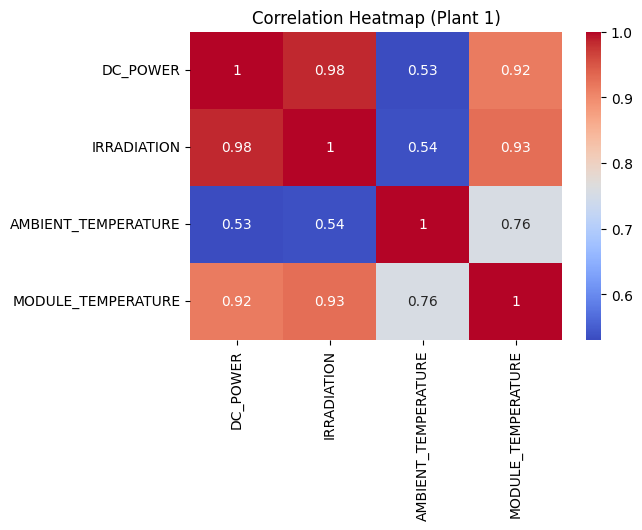


Correlation Heatmap for Plant 2:


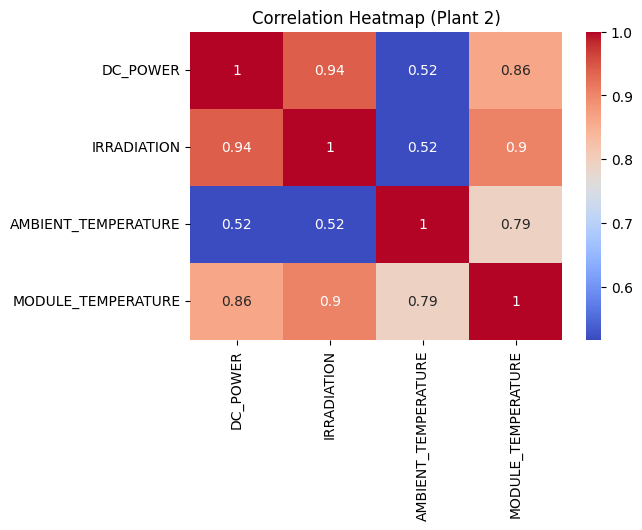


Comparing DC Power output (first 500 samples):


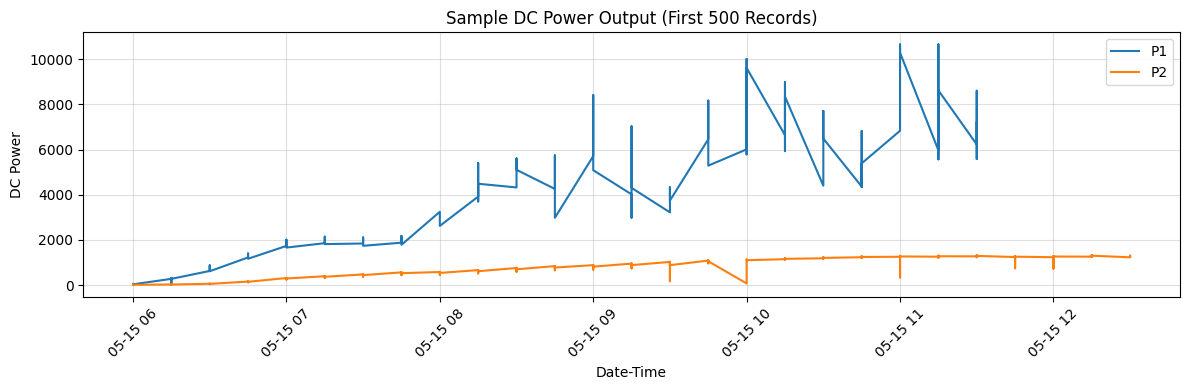

In [ ]:
# ================= EDA =================

# --- Plot 1: Correlation Heatmap for Plant 1 ---
print("Correlation Heatmap for Plant 1:")
plt.figure(figsize=(6, 4)) # Smaller figure size for single plot
sns.heatmap(df_p1[['DC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Plant 1)')
plt.show()

# --- Plot 2: Correlation Heatmap for Plant 2 ---
print("\nCorrelation Heatmap for Plant 2:")
plt.figure(figsize=(6, 4))
sns.heatmap(df_p2[['DC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Plant 2)')
plt.show()

# --- Plot 3: Sample DC Power Output (Your code was correct) ---
# This plot is excellent as it VISUALLY CONFIRMS the different scales.
print("\nComparing DC Power output (first 500 samples):")
plt.figure(figsize=(12,4))
# We can just iterate over our two dataframes
plt.plot(df_p1['DATE_TIME'].iloc[:500], df_p1['DC_POWER'].iloc[:500], label='P1')
plt.plot(df_p2['DATE_TIME'].iloc[:500], df_p2['DC_POWER'].iloc[:500], label='P2')
plt.legend()
plt.title("Sample DC Power Output (First 500 Records)")
plt.xlabel("Date-Time")
plt.ylabel("DC Power")
plt.xticks(rotation=45)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


--- Plant 1 Trend ---


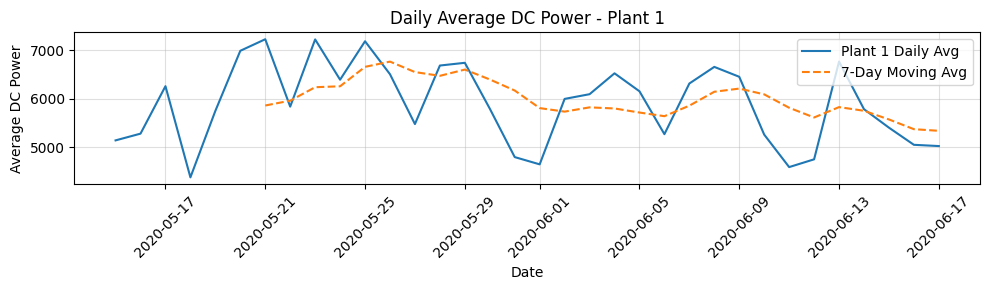


--- Plant 2 Trend ---


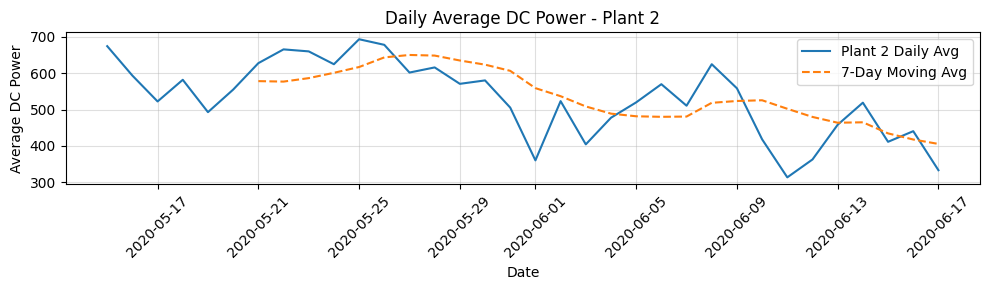

In [ ]:
# ================= TREND ANALYSIS (Corrected) =================

# --- Function to plot daily trend for any dataframe ---
def plot_daily_trend(dataframe, plant_name):
    """Calculates and plots the daily average and 7-day moving avg."""

    # Create 'DATE' column
    df_temp = dataframe.copy()
    df_temp['DATE'] = df_temp['DATE_TIME'].dt.date

    # Calculate daily mean DC Power
    daily = df_temp.groupby('DATE')['DC_POWER'].mean().reset_index()

    # Plot trend
    plt.figure(figsize=(10,3))
    plt.plot(daily['DATE'], daily['DC_POWER'], label=f'{plant_name} Daily Avg', color='tab:blue')
    plt.plot(daily['DATE'], daily['DC_POWER'].rolling(7).mean(),
             label='7-Day Moving Avg', color='tab:orange', linestyle='--')

    plt.title(f"Daily Average DC Power - {plant_name}")
    plt.xlabel("Date")
    plt.ylabel("Average DC Power")
    plt.legend()
    plt.grid(alpha=0.4)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Run the analysis for each plant separately ---
print("--- Plant 1 Trend ---")
plot_daily_trend(df_p1, 'Plant 1')

print("\n--- Plant 2 Trend ---")
plot_daily_trend(df_p2, 'Plant 2')


In [ ]:
9# ================= FEATURE ENGINEERING (Corrected) =================

def create_features(df):
    """Adds time-based and lag features to a single-plant dataframe."""

    # Make a copy to avoid modifying the original df_p1 or df_p2
    df_feat = df.copy()

    # 1. Time-based features
    df_feat['hour'] = df_feat['DATE_TIME'].dt.hour
    df_feat['dayofyear'] = df_feat['DATE_TIME'].dt.dayofyear

    # 2. Lag features (past DC_POWER values)
    # No groupby() needed, as this df is for one plant
    for lag in [1, 2, 3, 24]:
        df_feat[f'lag_{lag}'] = df_feat['DC_POWER'].shift(lag)

    # 3. Rolling mean feature
    # (Mean of the last 3 shifted values: t-1, t-2, t-3)
    # No groupby() or reset_index() needed
    df_feat['rmean_3'] = df_feat['DC_POWER'].shift(1).rolling(3).mean()

    # 4. Drop rows with NaNs created by shift/rolling
    df_feat = df_feat.dropna()

    return df_feat

# --- Run Feature Engineering for each plant ---
print("--- Creating features for Plant 1 ---")
df_p1_features = create_features(df_p1)
display(df_p1_features.head())

print("\n--- Creating features for Plant 2 ---")
df_p2_features = create_features(df_p2)
display(df_p2_features.head())

--- Creating features for Plant 1 ---


,DATE_TIME,PLANT,DC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,hour,dayofyear,lag_1,lag_2,lag_3,lag_24,rmean_3
24,2020-05-15 06:15:00,P1,311.428571,0.022282,24.011635,22.353459,6,136,316.250000,318.625000,310.571429,37.142857,315.148810
25,2020-05-15 06:15:00,P1,61.125000,0.022282,24.011635,22.353459,6,136,311.428571,316.250000,318.625000,53.500000,315.434524
26,2020-05-15 06:15:00,P1,315.000000,0.022282,24.011635,22.353459,6,136,61.125000,311.428571,316.250000,58.000000,229.601190
27,2020-05-15 06:15:00,P1,303.428571,0.022282,24.011635,22.353459,6,136,315.000000,61.125000,311.428571,58.428571,229.184524
28,2020-05-15 06:15:00,P1,296.333333,0.022282,24.011635,22.353459,6,136,303.428571,315.000000,61.125000,54.375000,226.517857



--- Creating features for Plant 2 ---


,DATE_TIME,PLANT,DC_POWER,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,hour,dayofyear,lag_1,lag_2,lag_3,lag_24,rmean_3
24,2020-05-15 06:15:00,P2,27.446667,0.021038,24.763911,24.356189,6,136,25.206667,27.433333,13.586667,15.406667,22.075556
25,2020-05-15 06:15:00,P2,24.642857,0.021038,24.763911,24.356189,6,136,27.446667,25.206667,27.433333,14.773333,26.695556
26,2020-05-15 06:15:00,P2,27.220000,0.021038,24.763911,24.356189,6,136,24.642857,27.446667,25.206667,15.380000,25.765397
27,2020-05-15 06:15:00,P2,26.228571,0.021038,24.763911,24.356189,6,136,27.220000,24.642857,27.446667,14.973333,26.436508
28,2020-05-15 06:15:00,P2,26.464286,0.021038,24.763911,24.356189,6,136,26.228571,27.220000,24.642857,15.160000,26.030476


In [ ]:
# ================= REGRESSION MODELS (Corrected) =================

# --- 1. Define Features ---
# This feature list looks excellent
features = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'hour', 'dayofyear', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'rmean_3'
]

# --- 2. Define Models ---
# We can define the models once
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42)
}

# --- 3. Create a function to run the entire process ---
def run_regression_suite(df_feat, plant_name):
    """Splits, scales, trains, and evaluates models for a single plant."""

    print(f"\n--- 🚀 Running Models for {plant_name} ---")

    # Use the correct, plant-specific dataframe
    X, y = df_feat[features], df_feat['DC_POWER']

    # Split without shuffling (keep time order)
    # Using random_state=42 for reproducibility, though shuffle=False is key
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2, random_state=42)

    # Scale features
    # A new, separate scaler is fit for each plant
    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train)
    X_test_s = sc.transform(X_test)

    # Train and predict
    preds = {}
    print("🔄 Training models...\n")
    for name, model in models.items():
        # Re-fit the model on the new plant's data
        model.fit(X_train_s, y_train)
        preds[name] = model.predict(X_test_s)

        rmse = np.sqrt(mean_squared_error(y_test, preds[name]))
        mae = mean_absolute_error(y_test, preds[name])
        r2 = r2_score(y_test, preds[name])
        print(f"{name:15s} → RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    print(f"\n✅ {plant_name} regression model training complete.")

    # Return the results so we can plot them later
    return y_test, preds

# --- 4. Run the suite for each plant ---
(y_test_p1, preds_p1) = run_regression_suite(df_p1_features, "Plant 1")
(y_test_p2, preds_p2) = run_regression_suite(df_p2_features, "Plant 2")


--- 🚀 Running Models for Plant 1 ---
🔄 Training models...

Linear Regression → RMSE: 487.7183, MAE: 303.6836, R²: 0.9806
Random Forest   → RMSE: 449.2446, MAE: 250.4122, R²: 0.9835
XGBoost         → RMSE: 445.9137, MAE: 244.3600, R²: 0.9838

✅ Plant 1 regression model training complete.

--- 🚀 Running Models for Plant 2 ---
🔄 Training models...

Linear Regression → RMSE: 94.9384, MAE: 46.5905, R²: 0.8971
Random Forest   → RMSE: 90.6907, MAE: 42.8759, R²: 0.9061
XGBoost         → RMSE: 91.4192, MAE: 43.3415, R²: 0.9046

✅ Plant 2 regression model training complete.


In [ ]:
# ================= METRICS SUMMARY =================

def metrics(y_true, y_pred):
    """Calculates RMSE, MAE, and R2."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# This list will hold all our results
all_rows = []

# --- 1. Get results from Regression models ---
# (Uses preds_p1 and y_test_p1 from the regression script)
print("Collecting Regression results for Plant 1...")
for model_name, predictions in preds_p1.items():
    rm, ma, r = metrics(y_test_p1, predictions)
    all_rows.append([model_name, rm, ma, r])


# --- 3. Create and display the final DataFrame ---
results = pd.DataFrame(all_rows, columns=['Model', 'RMSE', 'MAE', 'R2'])

print("\n--- 📊 FINAL RESULTS SUMMARY (PLANT 1) ---")
print(results.sort_values(by='R2', ascending=False).to_markdown(index=False))


--- 📊 FINAL RESULTS SUMMARY (PLANT 1) ---
| Model             |    RMSE |     MAE |       R2 |
|:------------------|--------:|--------:|---------:|
| XGBoost           | 445.914 | 244.36  | 0.983786 |
| Random Forest     | 449.245 | 250.412 | 0.983542 |
| Linear Regression | 487.718 | 303.684 | 0.980603 |


Plotting regression model results for Plant 1...


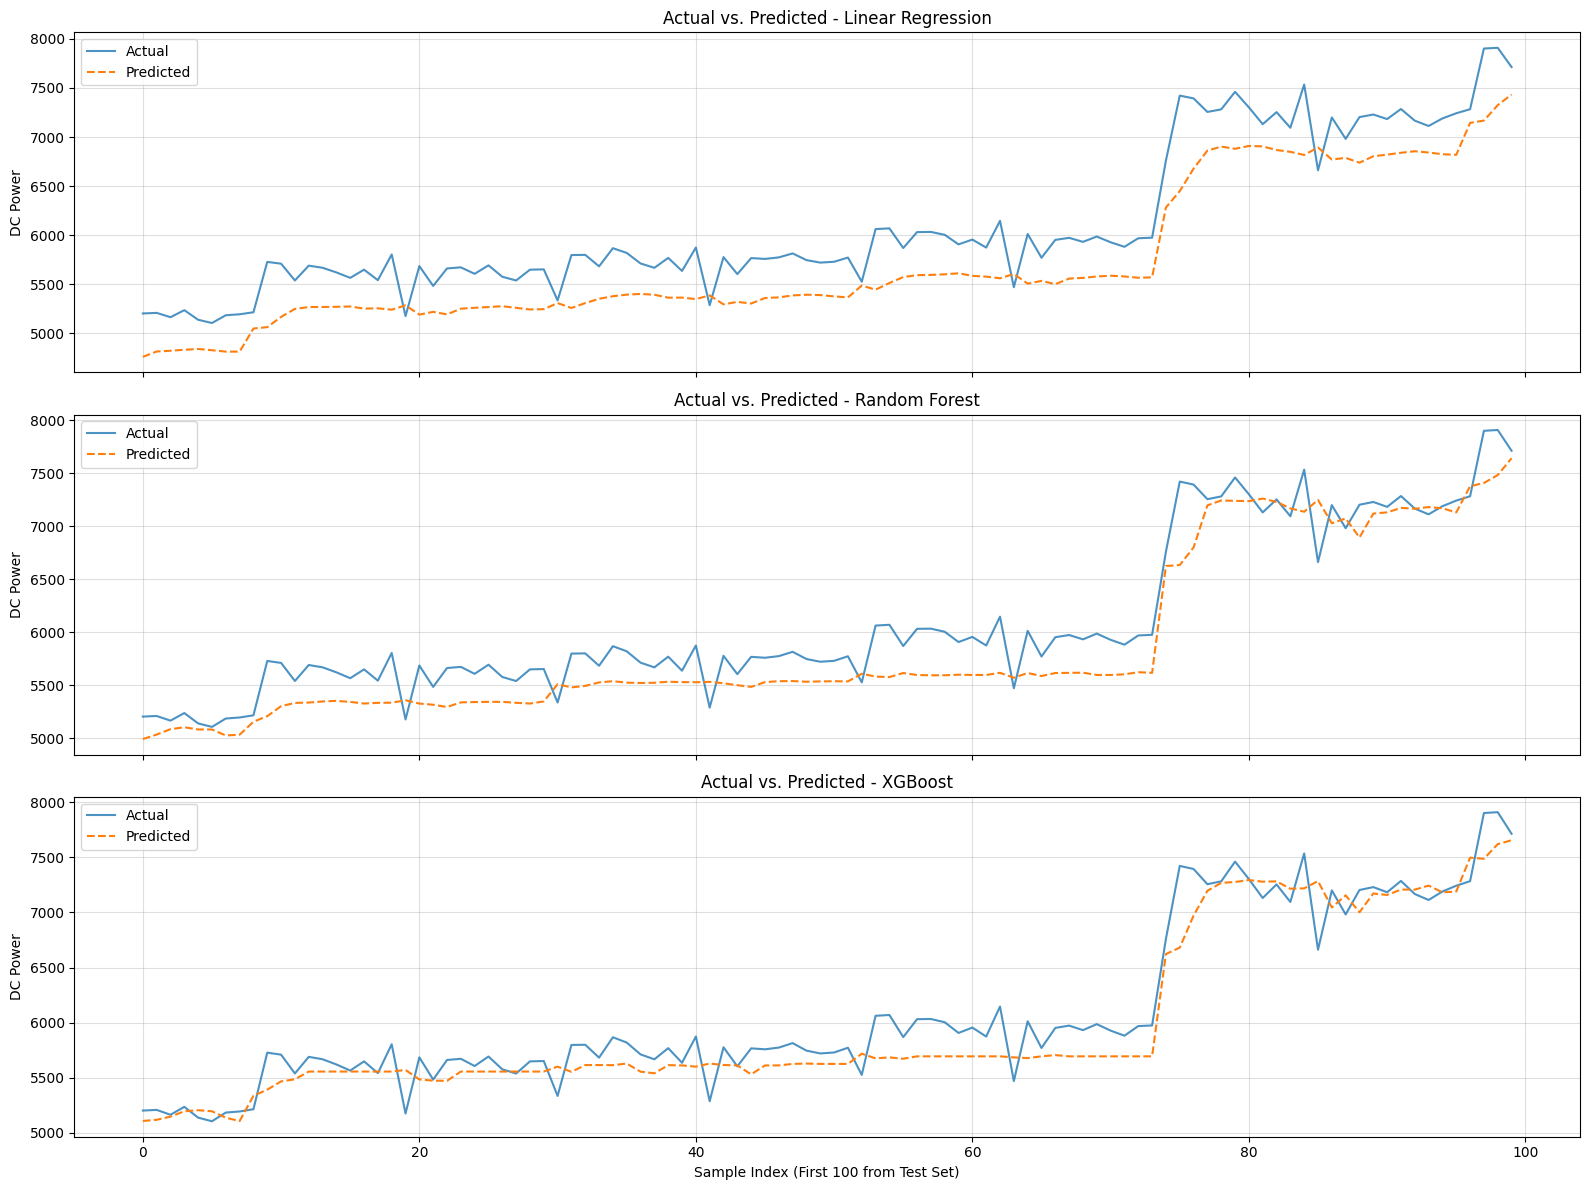

In [ ]:
# ================= REGRESSION PLOTS =================

# --- 1. Define models to plot and number of samples ---
# We will plot the first 400 samples of the test set
models_to_plot = ['Linear Regression', 'Random Forest', 'XGBoost']
n_samples = 100

# Get the actual "ground truth" data for this slice
# We must reset the index so 'actuals' plots correctly from 0
actuals = y_test_p1.reset_index(drop=True).iloc[:n_samples]

# --- 2. Create Subplots ---
# Create a figure with 3 rows, 1 column of plots
# 'sharex=True' links the x-axis for all plots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), sharex=True)

print("Plotting regression model results for Plant 1...")

# --- 3. Loop and Plot ---
# Loop over each model and its corresponding axis
for ax, model_name in zip(axes, models_to_plot):

    # Get the predictions for this model
    # We must also reset the index for the predictions
    preds_slice = pd.Series(preds_p1[model_name]).iloc[:n_samples]

    # Plot Actual vs. Predicted
    ax.plot(actuals, label='Actual', color='tab:blue', alpha=0.8)
    ax.plot(preds_slice, label='Predicted', color='tab:orange', linestyle='--')

    # --- 4. Formatting ---
    ax.set_title(f"Actual vs. Predicted - {model_name}")
    ax.set_ylabel("DC Power")
    ax.legend()
    ax.grid(alpha=0.4)

# Set the x-label only on the bottom-most plot
axes[-1].set_xlabel(f"Sample Index (First {n_samples} from Test Set)")

# Automatically adjust spacing
plt.tight_layout()
plt.show()


--- LSTM for Plant 1 ---
Epoch 1/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0134 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0059 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0050 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0045 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 5/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0041 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 6/15
206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0039
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0038 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 7/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0035 - val_loss: 0.0038 - learning_rate: 5.0000e-04
Epoch 8/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss:

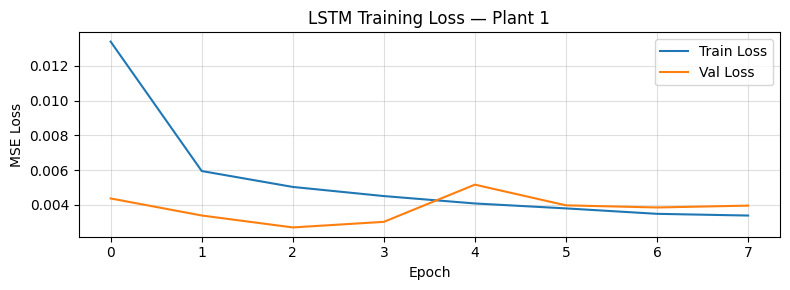

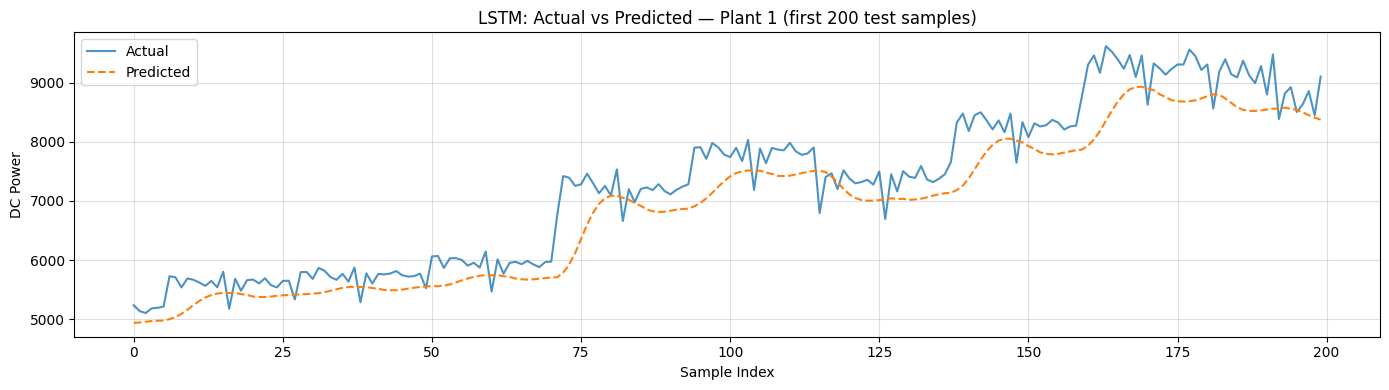


--- LSTM for Plant 2 ---
Epoch 1/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0133 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 2/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0093 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 3/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0087 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 4/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0083 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 5/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0080 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 6/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0078 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 7/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0077 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 8/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0076 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 9/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0075 - val_loss: 0.0074

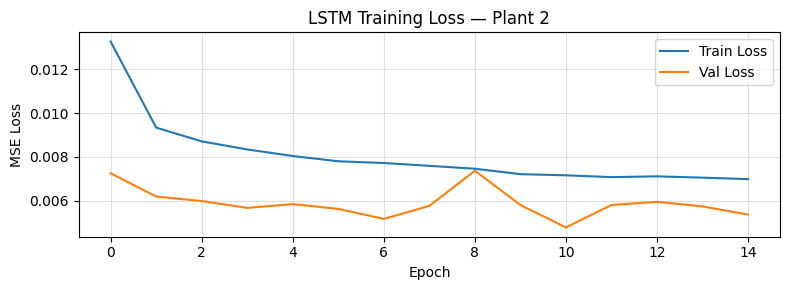

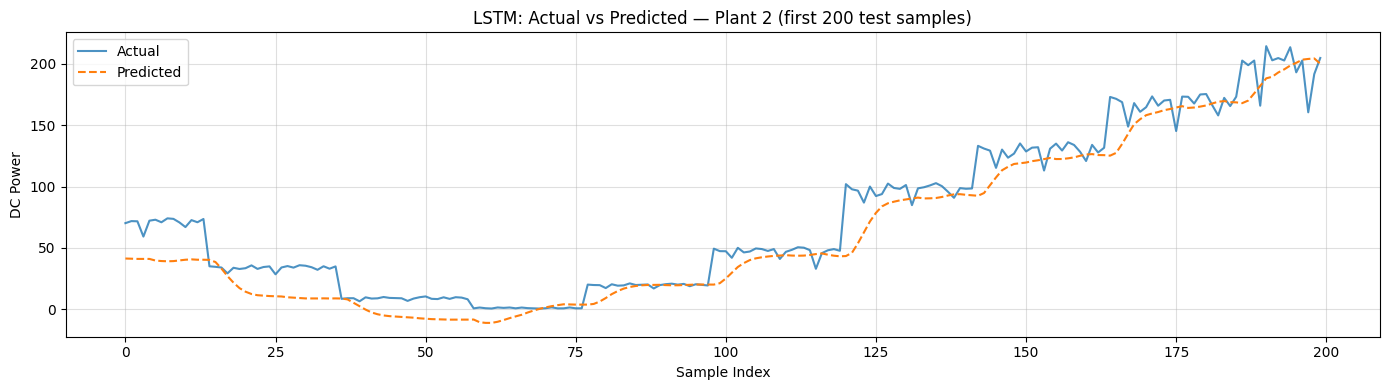

In [ ]:
# ================= LSTM MODEL =================
# LSTM requires sequence data — reshape input into (samples, timesteps, features)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Reduced TIMESTEPS slightly for speed, but keeping enough for temporal patterns
TIMESTEPS = 15

def build_sequences(X_arr, y_arr, timesteps=TIMESTEPS):
    """Convert flat arrays into overlapping windows."""
    Xs, ys = [], []
    for i in range(len(X_arr) - timesteps):
        Xs.append(X_arr[i : i + timesteps])
        ys.append(y_arr[i + timesteps])
    return np.array(Xs), np.array(ys)


def run_lstm(df_feat, plant_name):
    """Train a stacked LSTM on one plant's feature-engineered data."""
    print(f"\n--- LSTM for {plant_name} ---")

    features_lstm = [
        'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
        'hour', 'dayofyear', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'rmean_3'
    ]

    # Ensure features exist in the dataframe before proceeding
    available_features = [f for f in features_lstm if f in df_feat.columns]
    X_raw = df_feat[available_features].values
    y_raw = df_feat['DC_POWER'].values

    # Scale
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
    X_scaled = x_scaler.fit_transform(X_raw)
    y_scaled = y_scaler.fit_transform(y_raw.reshape(-1, 1)).flatten()

    # Sequence windows
    X_seq, y_seq = build_sequences(X_scaled, y_scaled, TIMESTEPS)

    # Train / Test split (80/20, no shuffle for time series)
    split = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    n_features = X_train.shape[2]

    # Build stacked LSTM
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(TIMESTEPS, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # Fast-training configuration
    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]

    # Train with reduced epochs and larger batch size for speed
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=15,             # Reduced from 60 to 15
        batch_size=128,        # Increased from 64 to 128 for faster steps
        callbacks=callbacks,
        verbose=1
    )

    # Predict & inverse-transform
    y_pred_scaled = model.predict(X_test).flatten()
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'LSTM':15s} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

    # Training-loss plot
    plt.figure(figsize=(8, 3))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'LSTM Training Loss — {plant_name}')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

    # Actual vs Predicted Visualization
    n_show = 200
    plt.figure(figsize=(14, 4))
    plt.plot(y_true[:n_show],  label='Actual',    color='tab:blue',   alpha=0.8)
    plt.plot(y_pred[:n_show],  label='Predicted', color='tab:orange', linestyle='--')
    plt.title(f'LSTM: Actual vs Predicted — {plant_name} (first {n_show} test samples)')
    plt.xlabel('Sample Index'); plt.ylabel('DC Power')
    plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()

    return y_true, y_pred, rmse, mae, r2, model


# Run LSTM on both plants
# Note: Ensure df_p1_features and df_p2_features are already created in your notebook
y_true_lstm_p1, y_pred_lstm_p1, lstm_rmse_p1, lstm_mae_p1, lstm_r2_p1, lstm_model_p1 = run_lstm(df_p1_features, 'Plant 1')
y_true_lstm_p2, y_pred_lstm_p2, lstm_rmse_p2, lstm_mae_p2, lstm_r2_p2, lstm_model_p2 = run_lstm(df_p2_features, 'Plant 2')

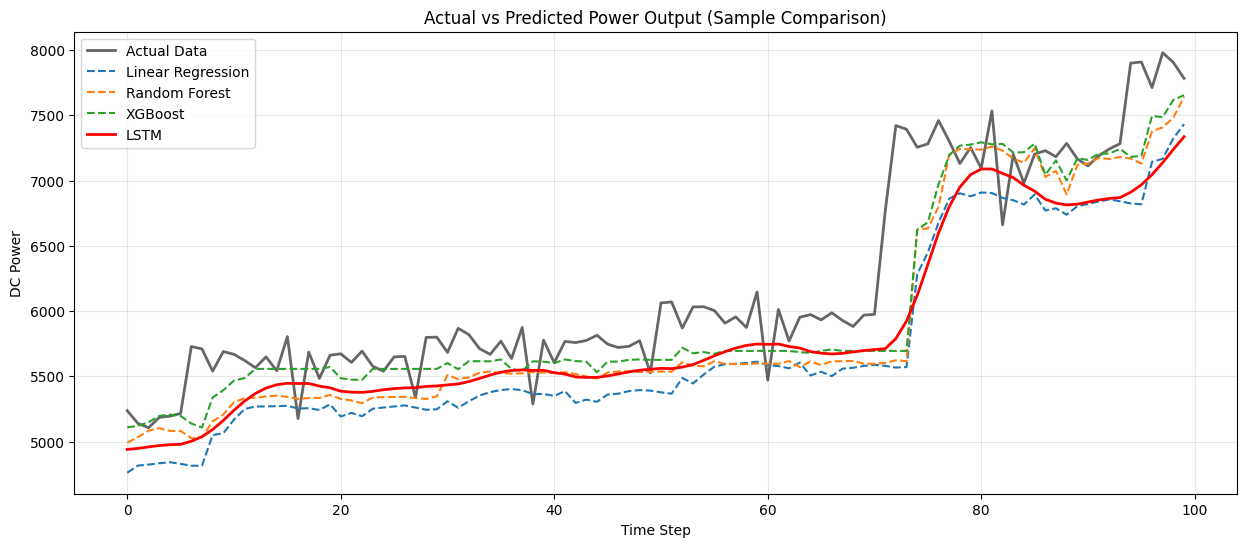

In [ ]:
# Assuming you want to see the first 100 test samples for clarity
n_samples = 100

# Extract predictions from the preds_p1 dictionary
y_pred_lr_p1 = preds_p1['Linear Regression']
y_pred_rf_p1 = preds_p1['Random Forest']
y_pred_xgb_p1 = preds_p1['XGBoost']

plt.figure(figsize=(15, 6))
plt.plot(y_true_lstm_p1[:n_samples], label='Actual Data', color='black', linewidth=2, alpha=0.6)
plt.plot(y_pred_lr_p1[:n_samples], label='Linear Regression', linestyle='--')
plt.plot(y_pred_rf_p1[:n_samples], label='Random Forest', linestyle='--')
plt.plot(y_pred_xgb_p1[:n_samples], label='XGBoost', linestyle='--')
plt.plot(y_pred_lstm_p1[:n_samples], label='LSTM', color='red', linewidth=2)

plt.title('Actual vs Predicted Power Output (Sample Comparison)')
plt.xlabel('Time Step')
plt.ylabel('DC Power')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- MODEL COMPARISON MATRIX ---
               Model        RMSE         MAE  R2_Score
0  Linear Regression  487.718272  303.683629  0.980603
1      Random Forest  449.244628  250.412206  0.983542
2            XGBoost  445.913675  244.360049  0.983786
3               LSTM  735.360384  445.587554  0.955922


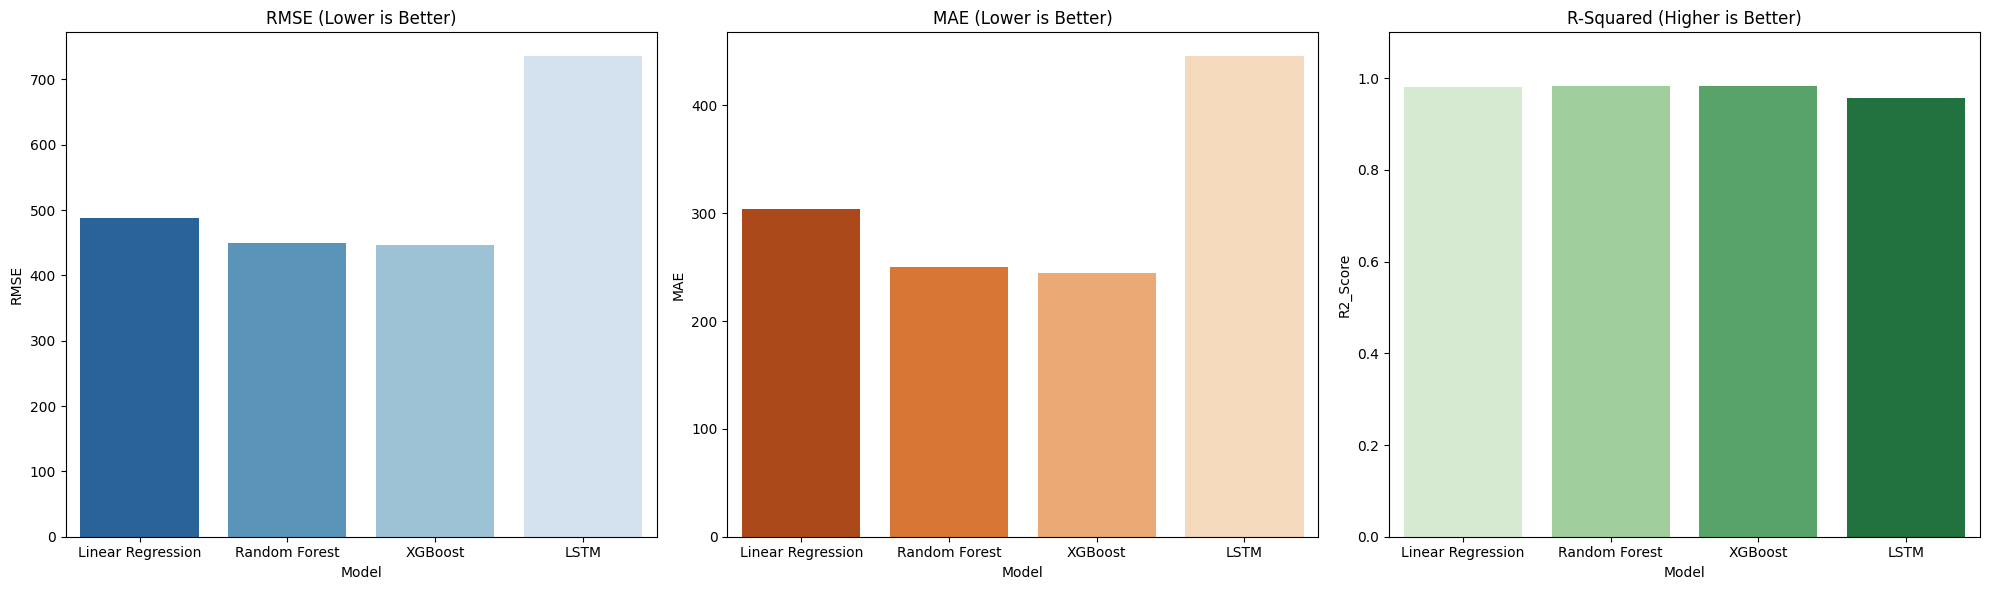

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Ensure numpy is imported

# 1. Create a helper function to collect all metrics
def get_metrics(y_true, y_pred, model_name):
    # Ensure both are flattened arrays
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2_Score': r2}

# 2. Compile all model results into a list
comparison_list = []

# Add Linear Regression (using y_test_p1 and preds_p1)
comparison_list.append(get_metrics(y_test_p1, preds_p1['Linear Regression'], 'Linear Regression'))

# Add Random Forest (using y_test_p1 and preds_p1)
comparison_list.append(get_metrics(y_test_p1, preds_p1['Random Forest'], 'Random Forest'))

# Add XGBoost (using y_test_p1 and preds_p1)
comparison_list.append(get_metrics(y_test_p1, preds_p1['XGBoost'], 'XGBoost'))

# Add LSTM (Use the unscaled/inverse_transformed values which are already y_true_lstm_p1 and y_pred_lstm_p1)
comparison_list.append(get_metrics(y_true_lstm_p1, y_pred_lstm_p1, 'LSTM'))

# 3. Create the Comparison Matrix (DataFrame)
df_matrix = pd.DataFrame(comparison_list)
print("--- MODEL COMPARISON MATRIX ---")
print(df_matrix)

# 4. Plotting the Comparison Graph
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot RMSE (Lower is Better)
sns.barplot(x='Model', y='RMSE', data=df_matrix, ax=axes[0], palette='Blues_r')
axes[0].set_title('RMSE (Lower is Better)')

# Plot MAE (Lower is Better)
sns.barplot(x='Model', y='MAE', data=df_matrix, ax=axes[1], palette='Oranges_r')
axes[1].set_title('MAE (Lower is Better)')

# Plot R2 Score (Higher is Better)
sns.barplot(x='Model', y='R2_Score', data=df_matrix, ax=axes[2], palette='Greens')
axes[2].set_title('R-Squared (Higher is Better)')
axes[2].set_ylim(0, 1.1) # R2 should be between 0 and 1

plt.tight_layout()
plt.show()